# Generalizar a mistura espacial (além do contorno do Rio)

O Kriging em `kriging_spatial_probability.ipynb` **não aprende a silhueta do Rio como um parâmetro**. Ele aprende uma **intensidade suave** condicionada aos pontos. A forma “parece o Rio” porque:

1. os casos só existem na mancha urbana / terra firme;
2. o grid de predição é o bbox do município;
3. Ordinary Kriging **propaga** essa estrutura para células vizinhas.

O que **é** transferível (a “ideia de mistura”) são coisas como:

- quantos **hotspots** (componentes) existem;
- **pesos** relativos entre componentes;
- **escala / anisotropia** de cada blob (quão espalhado, alongado);
- **sobreposição** entre doenças (mesma área vs. focos distintos);
- dinâmica temporal (nascer/morrer de focos).

Este notebook explora caminhos para **mudar a geometria do mapa** mantendo essa mistura.

## Mapa mental: 3 camadas

| Camada | O que é | Como generalizar |
|--------|---------|------------------|
| **Suporte** $S$ | Onde a densidade pode ser > 0 (cidade, ilha, retângulo) | Máscara / domínio novo |
| **Mistura** $\sum_k w_k f_k$ | Hotspots (Gaussianas, kernels, …) | GMM / componentes do Kriging |
| **Observação** | Casos amostrados + ruído clínico | Gerador do env |

Objetivo prático: extrair a mistura do Rio e **recolocá-la** em outro suporte $S'$.

```text
casos Rio  →  (opcional Kriging)  →  GMM / componentes
                                      ↓
                         transformada afim / warp
                                      ↓
                         densidade em S'  →  amostrar casos
```

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.mixture import GaussianMixture

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dengue_envs.data.kriging import (
    DEFAULT_RIO_BBOX_LONLAT,
    GridSpec,
    bbox_lonlat_to_projected,
    intensity_surface_from_points,
    load_zikario_cases,
    normalize_probability,
)

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(0)

GPKG = ROOT / "dengue_envs" / "data" / "zikario.gpkg"
print("gpkg:", GPKG.exists())

gpkg: True


## 0. Recarregar casos (ou usar um subconjunto rápido)

Para exploração, um subsample por doença basta. Se já tiver o `.npz` exportado do outro notebook, pode carregar as superfícies e pular o Kriging.

In [8]:
cases = load_zikario_cases(
    GPKG,
    years=(2015, 2016),
    bbox_lonlat=DEFAULT_RIO_BBOX_LONLAT,
    diseases=("Dengue", "Chikungunya", "Zika"),
)
print(cases["Doenca"].value_counts())

xmin, xmax, ymin, ymax = bbox_lonlat_to_projected(DEFAULT_RIO_BBOX_LONLAT)
print(f"bbox Rio (m): x=[{xmin:.0f},{xmax:.0f}] y=[{ymin:.0f},{ymax:.0f}]")

samples = {}
for d in ("Dengue", "Chikungunya", "Zika"):
    sub = cases[cases["Doenca"] == d][["x", "y"]].to_numpy()
    samples[d] = sub
    print(d, "amostra GMM:", len(sub))

Doenca
Dengue         52255
Zika           40872
Chikungunya    14071
Name: count, dtype: int64
bbox Rio (m): x=[622893,695168] y=[7444144,7489191]
Dengue amostra GMM: 52255
Chikungunya amostra GMM: 14071
Zika amostra GMM: 40872


## 1. Extrair a mistura com um GMM

Ideia: cada doença ≈ $\sum_k w_k \mathcal{N}(\mu_k, \Sigma_k)$.

- $K$ controla a complexidade (comece com 4–8).
- Compare BIC para escolher $K$.
- Os $(\mu, \Sigma, w)$ são a **assinatura transferível**; a silhueta do Rio não entra como parâmetro.

In [9]:
def fit_gmm(xy: np.ndarray, k_grid=(3, 4, 5, 6, 8), random_state=0):
    """Ajusta GMMs e devolve o de menor BIC."""
    best, best_bic, rows = None, np.inf, []
    for k in k_grid:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=random_state,
            max_iter=300,
            n_init=3,
        )
        gmm.fit(xy)
        bic = gmm.bic(xy)
        rows.append((k, bic, gmm.aic(xy)))
        if bic < best_bic:
            best, best_bic = gmm, bic
    return best, rows


gmms = {}
for d, xy in samples.items():
    gmm, rows = fit_gmm(xy)
    gmms[d] = gmm
    print(f"\n{d}: melhor K={gmm.n_components}")
    for k, bic, aic in rows:
        mark = " <--" if k == gmm.n_components else ""
        print(f"  K={k}: BIC={bic:.1f} AIC={aic:.1f}{mark}")


Dengue: melhor K=8
  K=3: BIC=2163240.1 AIC=2163089.4
  K=4: BIC=2157911.1 AIC=2157707.3
  K=5: BIC=2134117.2 AIC=2133860.2
  K=6: BIC=2131732.7 AIC=2131422.5
  K=8: BIC=2126390.6 AIC=2125974.0 <--

Chikungunya: melhor K=8
  K=3: BIC=574963.6 AIC=574835.2
  K=4: BIC=573361.1 AIC=573187.4
  K=5: BIC=571715.0 AIC=571496.0
  K=6: BIC=571105.8 AIC=570841.5
  K=8: BIC=568406.4 AIC=568051.4 <--

Zika: melhor K=8
  K=3: BIC=1714575.0 AIC=1714428.5
  K=4: BIC=1710993.4 AIC=1710795.2
  K=5: BIC=1706295.0 AIC=1706045.0
  K=6: BIC=1701914.5 AIC=1701612.9
  K=8: BIC=1701538.3 AIC=1701133.3 <--


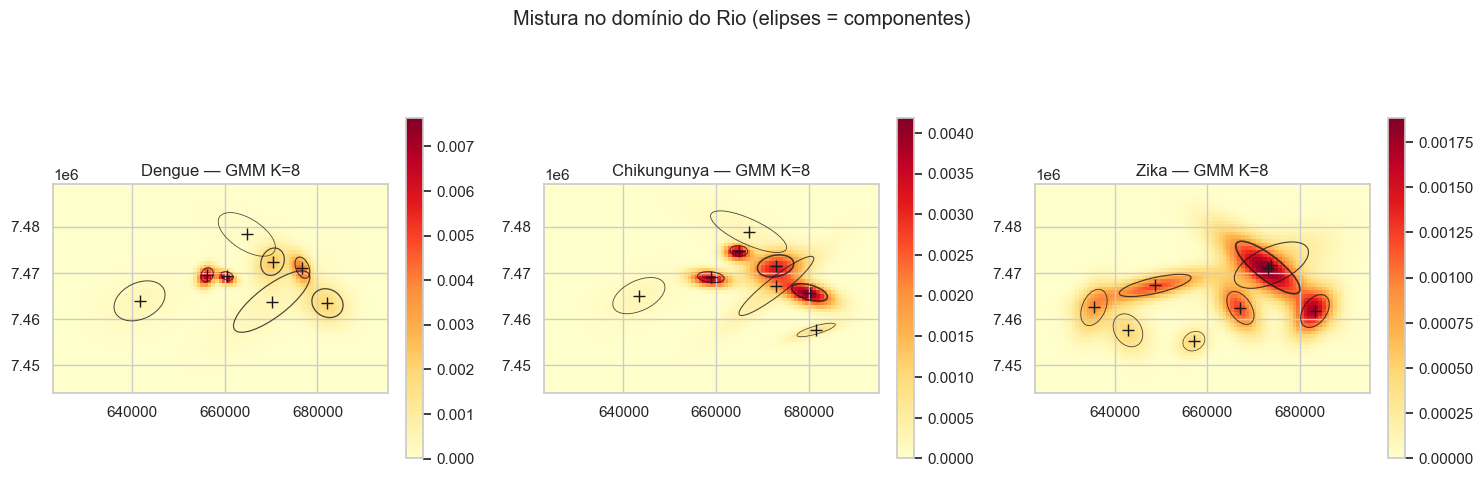

In [10]:
def gmm_density_on_grid(gmm: GaussianMixture, grid: GridSpec) -> np.ndarray:
    xs, ys = grid.centers()
    XX, YY = np.meshgrid(xs, ys)
    pts = np.column_stack([XX.ravel(), YY.ravel()])
    # score_samples = log densidade; exp → densidade não normalizada no grid discreto
    dens = np.exp(gmm.score_samples(pts)).reshape(grid.ny, grid.nx)
    return normalize_probability(dens)


rio_grid = GridSpec(xmin, xmax, ymin, ymax, cell_size=800.0)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, d in zip(axes, ("Dengue", "Chikungunya", "Zika")):
    prob = gmm_density_on_grid(gmms[d], rio_grid)
    ext = [xmin, xmax, ymin, ymax]
    im = ax.imshow(prob, origin="lower", extent=ext, aspect="equal", cmap="YlOrRd")
    # elipses dos componentes (1 desvio)
    for k in range(gmms[d].n_components):
        mean = gmms[d].means_[k]
        cov = gmms[d].covariances_[k]
        w = gmms[d].weights_[k]
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse

        e = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            fill=False,
            ec="k",
            lw=1.2 * (0.4 + 2 * w),
            alpha=0.8,
        )
        ax.add_patch(e)
        ax.plot(*mean, "k+", ms=8)
    ax.set_title(f"{d} — GMM K={gmms[d].n_components}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Mistura no domínio do Rio (elipses = componentes)", y=1.02)
plt.tight_layout()
plt.show()

## 2. Transformada afim: mesma mistura, outro lugar/escala/rotação

Se $x' = s R_\theta (x - c) + t$, a mistura continua a mesma ideia: só muda onde ela “mora”.

Isso já responde: **sim, dá para mudar a forma aparente do mapa** (bounding box, orientação) **sem reaprender** o Kriging.

c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


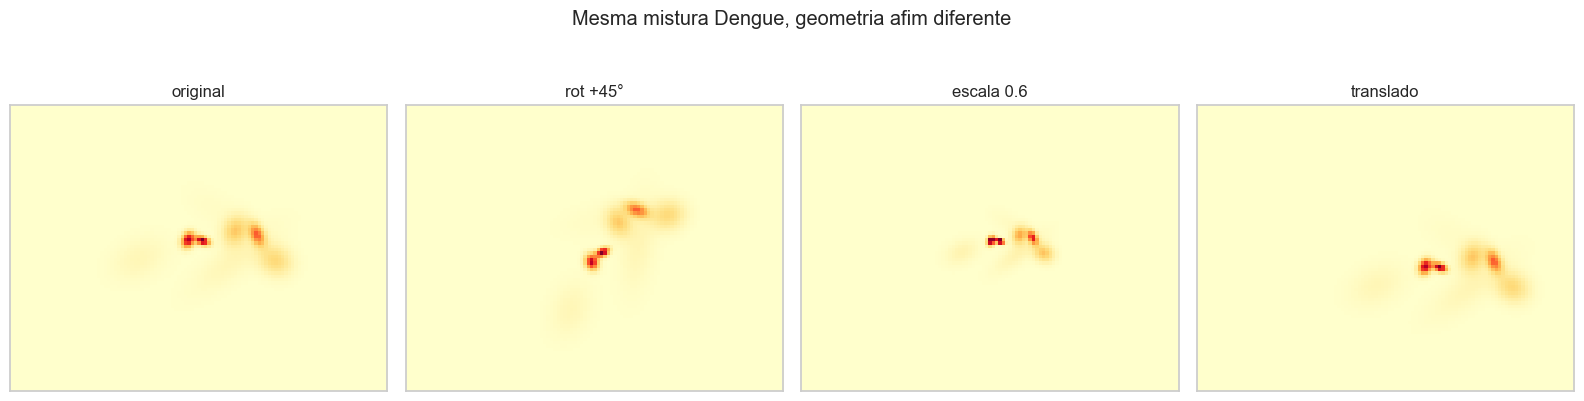

In [11]:
def gmm_from_params(weights, means, covariances) -> GaussianMixture:
    """Monta um GaussianMixture já 'fitted' a partir de parâmetros explícitos.

    O sklearn só expõe score_samples após fit(); usamos as próprias médias como
    X (n_samples == n_components) e em seguida sobrescrevemos os parâmetros.
    """
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    covariances = np.asarray(covariances, dtype=float)
    n = len(weights)
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        weights_init=weights,
        means_init=means,
        precisions_init=np.linalg.inv(covariances),
        max_iter=1,
        reg_covar=1e-6,
    )
    gmm.fit(means)  # n_samples == n_components (nunca 2 < K)
    gmm.weights_ = weights / weights.sum()
    gmm.means_ = means
    gmm.covariances_ = covariances
    # estabiliza Cholesky das precisões
    precisions = np.linalg.inv(covariances)
    chol = []
    for p in precisions:
        p = 0.5 * (p + p.T)
        chol.append(np.linalg.cholesky(p + 1e-9 * np.eye(p.shape[0])))
    gmm.precisions_cholesky_ = np.asarray(chol)
    return gmm


def transform_gmm(gmm: GaussianMixture, *, scale=1.0, theta_deg=0.0, translation=(0.0, 0.0), center=None):
    """Cria um GMM novo com médias/covariâncias transformadas (pesos iguais)."""
    theta = np.radians(theta_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    t = np.asarray(translation, dtype=float)
    if center is None:
        center = gmm.means_.mean(axis=0)
    center = np.asarray(center, dtype=float)

    means, covs = [], []
    for mu, cov in zip(gmm.means_, gmm.covariances_):
        mu2 = scale * (R @ (mu - center)) + center + t
        cov2 = (scale**2) * (R @ cov @ R.T)
        means.append(mu2)
        covs.append(cov2)
    return gmm_from_params(gmm.weights_, means, covs)


base = gmms["Dengue"]
center = base.means_.mean(axis=0)
variants = {
    "original": base,
    "rot +45°": transform_gmm(base, theta_deg=45, center=center),
    "escala 0.6": transform_gmm(base, scale=0.6, center=center),
    "translado": transform_gmm(base, translation=(15000, -8000), center=center),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, g) in zip(axes, variants.items()):
    # grid um pouco expandido para caber as variantes
    g_grid = GridSpec(xmin - 20000, xmax + 20000, ymin - 20000, ymax + 20000, 1000.0)
    prob = gmm_density_on_grid(g, g_grid)
    ext = [g_grid.xmin, g_grid.xmax, g_grid.ymin, g_grid.ymax]
    ax.imshow(prob, origin="lower", extent=ext, aspect="equal", cmap="YlOrRd")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Mesma mistura Dengue, geometria afim diferente", y=1.05)
plt.tight_layout()
plt.show()

## 3. Trocar o suporte $S$: máscara geométrica

Aqui a densidade da mistura é **multiplicada por uma máscara** (disco, anel, dois núcleos urbanos, retângulo) e renormalizada.

$$P'(x) \propto P_{\text{mistura}}(x)\, 1_S(x)$$

Isso muda a silhueta “tipo cidade”, mantendo a lógica de vários focos.

c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


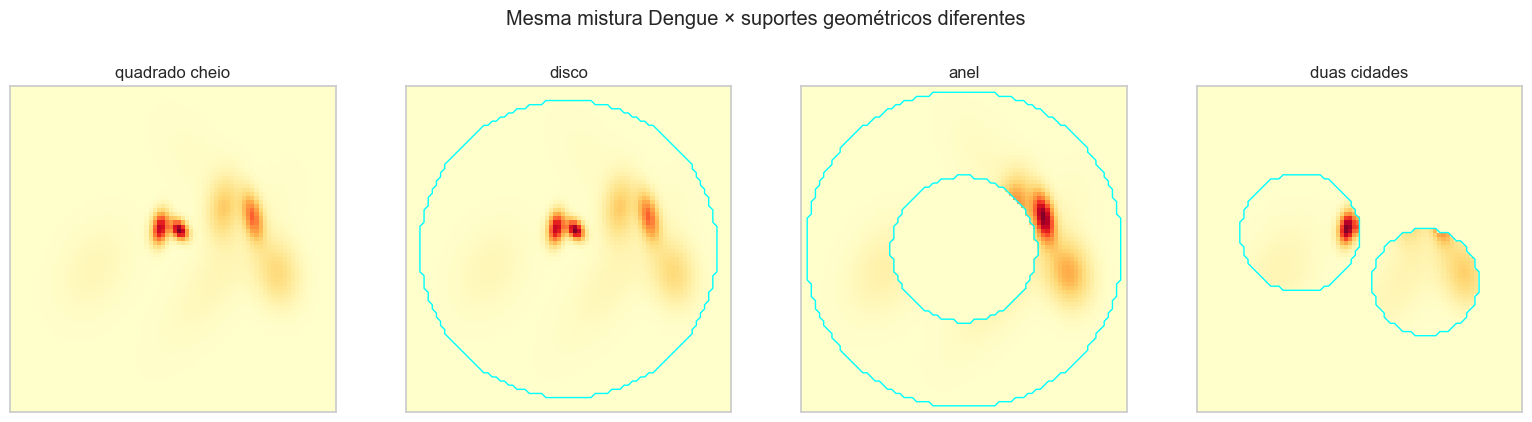

In [12]:
def make_square_grid(size_m=40000.0, cell=500.0, origin=(0.0, 0.0)):
    ox, oy = origin
    return GridSpec(ox, ox + size_m, oy, oy + size_m, cell)


def mask_disk(grid: GridSpec, center, radius):
    XX, YY = grid.mesh()
    return (XX - center[0]) ** 2 + (YY - center[1]) ** 2 <= radius**2


def mask_ring(grid: GridSpec, center, r_in, r_out):
    XX, YY = grid.mesh()
    d2 = (XX - center[0]) ** 2 + (YY - center[1]) ** 2
    return (d2 >= r_in**2) & (d2 <= r_out**2)


def mask_two_blobs(grid: GridSpec, c1, r1, c2, r2):
    return mask_disk(grid, c1, r1) | mask_disk(grid, c2, r2)


def place_mixture_on_support(gmm: GaussianMixture, grid: GridSpec, mask: np.ndarray) -> np.ndarray:
    dens = gmm_density_on_grid(gmm, grid)
    dens = dens * mask.astype(float)
    return normalize_probability(dens)


# Recoloca a mistura Dengue num domínio sintético [0, L]^2
L = 40000.0
synth_grid = make_square_grid(L, cell=500.0)
cx, cy = L / 2, L / 2

# Primeiro: mapear GMM do Rio → coordenadas do quadrado (normalizar bbox → [0,L]^2)
def gmm_rio_to_unit_square(gmm, bbox, L=L):
    """Mapeia médias/covariâncias do bbox do Rio para o quadrado [0, L]^2."""
    x0, x1, y0, y1 = bbox
    sx, sy = L / (x1 - x0), L / (y1 - y0)
    S = np.diag([sx, sy])
    means, covs = [], []
    for mu, cov in zip(gmm.means_, gmm.covariances_):
        mu2 = np.array([(mu[0] - x0) * sx, (mu[1] - y0) * sy])
        cov2 = S @ cov @ S.T
        means.append(mu2)
        covs.append(cov2)
    return gmm_from_params(gmm.weights_, means, covs)


dengue_sq = gmm_rio_to_unit_square(gmms["Dengue"], (xmin, xmax, ymin, ymax), L)

supports = {
    "quadrado cheio": np.ones((synth_grid.ny, synth_grid.nx), dtype=bool),
    "disco": mask_disk(synth_grid, (cx, cy), 0.45 * L),
    "anel": mask_ring(synth_grid, (cx, cy), 0.22 * L, 0.48 * L),
    "duas cidades": mask_two_blobs(
        synth_grid, (0.32 * L, 0.55 * L), 0.18 * L, (0.70 * L, 0.40 * L), 0.16 * L
    ),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, m) in zip(axes, supports.items()):
    prob = place_mixture_on_support(dengue_sq, synth_grid, m)
    ax.imshow(prob, origin="lower", extent=[0, L, 0, L], aspect="equal", cmap="YlOrRd")
    ax.contour(m.astype(float), levels=[0.5], extent=[0, L, 0, L], colors="cyan", linewidths=1.0)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Mesma mistura Dengue × suportes geométricos diferentes", y=1.05)
plt.tight_layout()
plt.show()

## 4. Mistura multi-doença no domínio sintético

Leva Dengue / Chik / Zika para o mesmo quadrado e compara:
- $P(x\mid\text{doença})$ lado a lado;
- mapa $\arg\max_d P(d\mid x)$ (quem “domina” cada célula).

c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


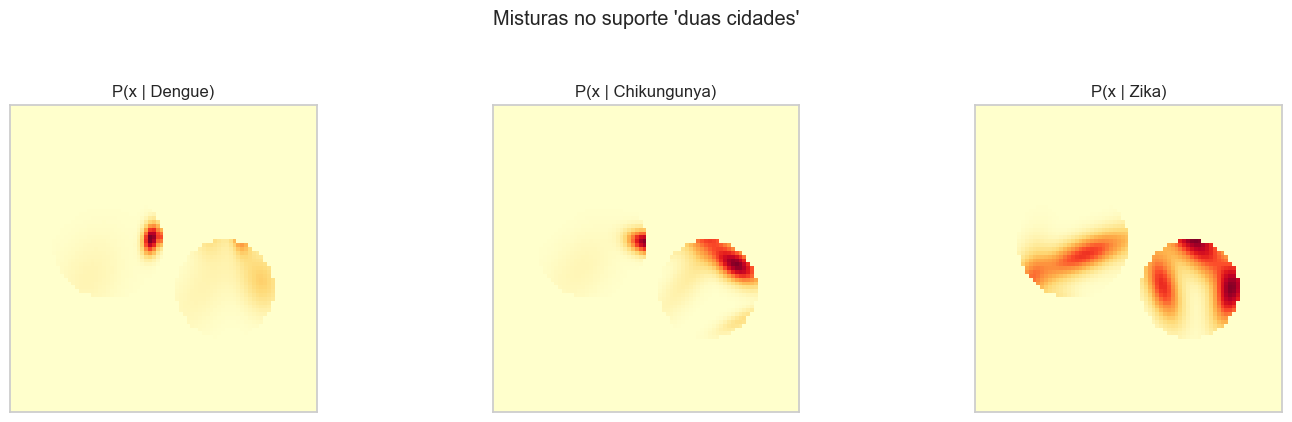

C:\Users\segun\AppData\Local\Temp\ipykernel_26204\1875972725.py:24: RuntimeWarning: invalid value encountered in divide
  stack = stack / stack.sum(axis=0, keepdims=True)


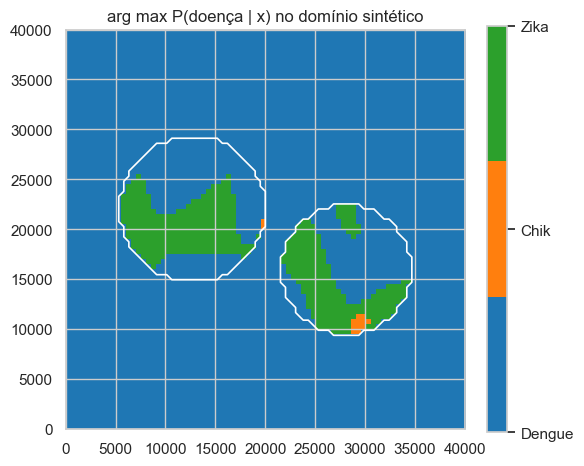

In [13]:
gmms_sq = {d: gmm_rio_to_unit_square(gmms[d], (xmin, xmax, ymin, ymax), L) for d in gmms}
mask = supports["duas cidades"]  # escolha um suporte interessante

probs = {d: place_mixture_on_support(gmms_sq[d], synth_grid, mask) for d in gmms_sq}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, probs):
    ax.imshow(probs[d], origin="lower", extent=[0, L, 0, L], aspect="equal", cmap="YlOrRd")
    ax.set_title(f"P(x | {d})")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Misturas no suporte 'duas cidades'", y=1.05)
plt.tight_layout()
plt.show()

# Dominância: usa intensidades relativas (já são probs espaciais; misturar com prior de prevalência)
prior = {
    "Dengue": 52255,
    "Zika": 40872,
    "Chikungunya": 14071,
}
total = sum(prior.values())
stack = np.stack([probs[d] * (prior[d] / total) for d in ("Dengue", "Chikungunya", "Zika")], axis=0)
stack = stack / stack.sum(axis=0, keepdims=True)
winner = stack.argmax(axis=0)  # 0 dengue, 1 chik, 2 zika

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.matplotlib.colors.ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c"])
im = ax.imshow(winner, origin="lower", extent=[0, L, 0, L], aspect="equal", cmap=cmap, vmin=0, vmax=2)
ax.contour(mask.astype(float), levels=[0.5], extent=[0, L, 0, L], colors="white", linewidths=1.2)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046)
cbar.ax.set_yticklabels(["Dengue", "Chik", "Zika"])
ax.set_title("arg max P(doença | x) no domínio sintético")
plt.tight_layout()
plt.show()

## 5. Amostrar casos no novo mapa (ponte para o env)

Com $P(x)$ no grid sintético, amostrar posições é trivial: escolha célula $\propto P$, depois uniforme dentro da célula.
Isso é o coração de um futuro `MixtureDensityGenerator` / `KrigingDensityGenerator`.

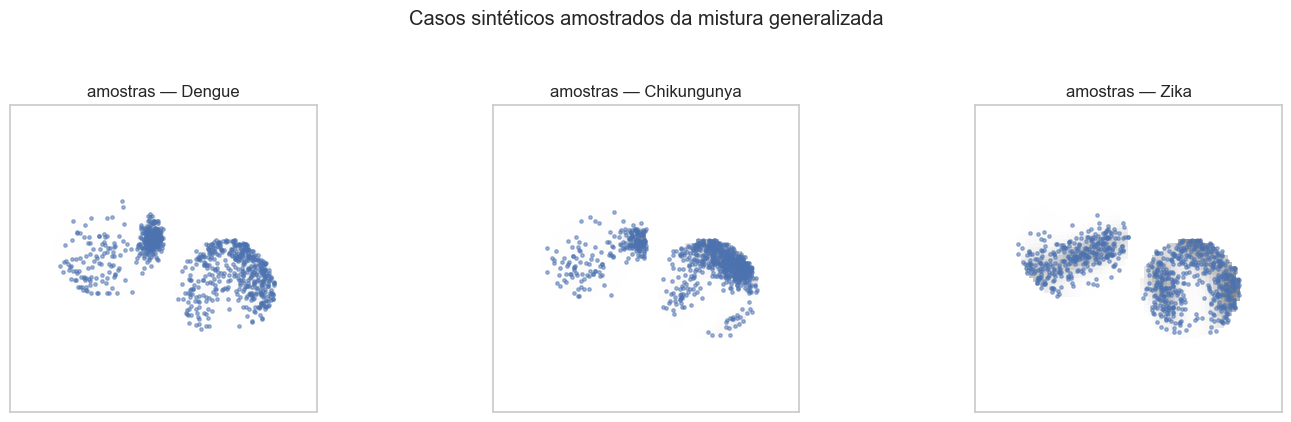

: 

In [ ]:
def sample_from_prob_grid(prob: np.ndarray, grid: GridSpec, n: int, rng=rng):
    flat = prob.ravel()
    flat = flat / flat.sum()
    idx = rng.choice(flat.size, size=n, replace=True, p=flat)
    iy, ix = np.unravel_index(idx, prob.shape)
    xs, ys = grid.centers()
    # jitter dentro da célula
    x = xs[ix] + (rng.random(n) - 0.5) * grid.cell_size
    y = ys[iy] + (rng.random(n) - 0.5) * grid.cell_size
    return x, y


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, ("Dengue", "Chikungunya", "Zika")):
    x, y = sample_from_prob_grid(probs[d], synth_grid, n=800)
    ax.imshow(probs[d], origin="lower", extent=[0, L, 0, L], aspect="equal", cmap="Greys", alpha=0.5)
    ax.scatter(x, y, s=6, alpha=0.5)
    ax.set_title(f"amostras — {d}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Casos sintéticos amostrados da mistura generalizada", y=1.05)
plt.tight_layout()
plt.show()

## 7. Checklist: o que levar para o gerador do ambiente

Quando estiver satisfeito visualmente:

1. Congelar um GMM (ou superfície) por doença + um suporte $S$ configurável no YAML.
2. Amostrar `(x,y,t,disease)` → `casedf` no formato `CASE_COLUMNS`.
3. Plugar em `KrigingDensityGenerator` / `MixtureDensityGenerator` sem mudar o env.
4. Benchmark: mesmo agente em `synthetic` vs `mixture_rio_warped`.

Parâmetros naturais no YAML:

```yaml
generator: mixture
support: two_cities   # square | disk | ring | two_cities | rio_mask
gmm_source: results/kriging/rio_gmm.pkl
scale: 1.0
rotation_deg: 0
```

Rodar:

```bash
poetry run jupyter notebook notebooks/generalizing_spatial_mixture.ipynb
```